In [1]:
import subprocess, sys
r = subprocess.run([sys.executable,'../performance_analytics.py'],capture_output=True,text=True)
print(r.stdout[-4000:])
if r.returncode!=0: print('ERR:',r.stderr[-800:])

fund_scorecard.csv saved (53 rows)
  ✓ chart_perf_06_scorecard.png

──────────────────────────────────────────────────────────────────────
TASK 8 | Benchmark Comparison + Tracking Error
──────────────────────────────────────────────────────────────────────
261
        index_name       date  close_value  daily_return  bm_return
261  NIFTY 100 TRI 2024-01-01      8871.72        1.1188        NaN
262  NIFTY 100 TRI 2024-01-02      9048.29       -1.9006   0.019903
263  NIFTY 100 TRI 2024-01-03      8950.47        0.5179  -0.010811
264  NIFTY 100 TRI 2024-01-04      8969.13       -0.2434   0.002085
265  NIFTY 100 TRI 2024-01-05      8958.85        0.3349  -0.001146
n100_3yr rows = 261
        index_name       date  close_value  daily_return  bm_return
261  NIFTY 100 TRI 2024-01-01      8871.72        1.1188        NaN
262  NIFTY 100 TRI 2024-01-02      9048.29       -1.9006   0.019903
263  NIFTY 100 TRI 2024-01-03      8950.47        0.5179  -0.010811
264  NIFTY 100 TRI 2024-01-04      8969

In [2]:
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROC   = '../data/processed'
CHARTS = '../reports/charts'

def show(f):
    p=os.path.join(CHARTS,f)
    if os.path.exists(p): display(Image(p,width=900))
    else: print('Not found:',p)

scorecard = pd.read_csv(os.path.join(PROC,'fund_scorecard.csv'))
ab        = pd.read_csv(os.path.join(PROC,'alpha_beta.csv'))
print('Scorecard shape:', scorecard.shape)
print('Alpha/Beta shape:', ab.shape)
print(scorecard[['overall_rank','scheme_name','composite_score',
                  'cagr_3yr_pct','sharpe_ratio']].head(10).to_string(index=False))

Scorecard shape: (53, 21)
Alpha/Beta shape: (50, 9)
 overall_rank                                    scheme_name  composite_score  cagr_3yr_pct  sharpe_ratio
            1     Aditya Birla Index Fund Direct Plan Growth            73.46         11.36      1.072138
            2             HDFC Children's Direct Plan Growth            70.77         20.19      1.434121
            3               SBI Multi Cap Direct Plan Growth            70.00         17.75      0.043907
            4              UTI Aggressive Direct Plan Growth            69.04         19.30      0.850969
            5 Aditya Birla Corporate Bond Direct Plan Growth            67.88         13.15      0.496076
            6  ICICI Prudential Small Cap Direct Plan Growth            66.44          9.06      1.023564
            7                SBI Sectoral Direct Plan Growth            65.67         17.27      0.492788
            8         Axis Short Duration Direct Plan Growth            65.29         15.95      0.5

# 📊 Performance Analytics — Bluestock Fintech MF Capstone
**Day 4 | Quantitative Fund Performance Analysis**

Covers: Daily returns · CAGR · Sharpe · Sortino · Alpha/Beta · Max Drawdown · Scorecard · Benchmark comparison

Risk-free rate: **Rf = 6.5%** (RBI repo rate proxy) | **252 trading days/year**


## 📈 Task 1 — Daily Returns Computation
**Formula:** `daily_return = NAV_t / NAV_t-1 − 1`

Validation: returns should be approximately normally distributed, centred near 0,
with equity funds showing ~1% daily σ and debt funds ~0.02% σ.


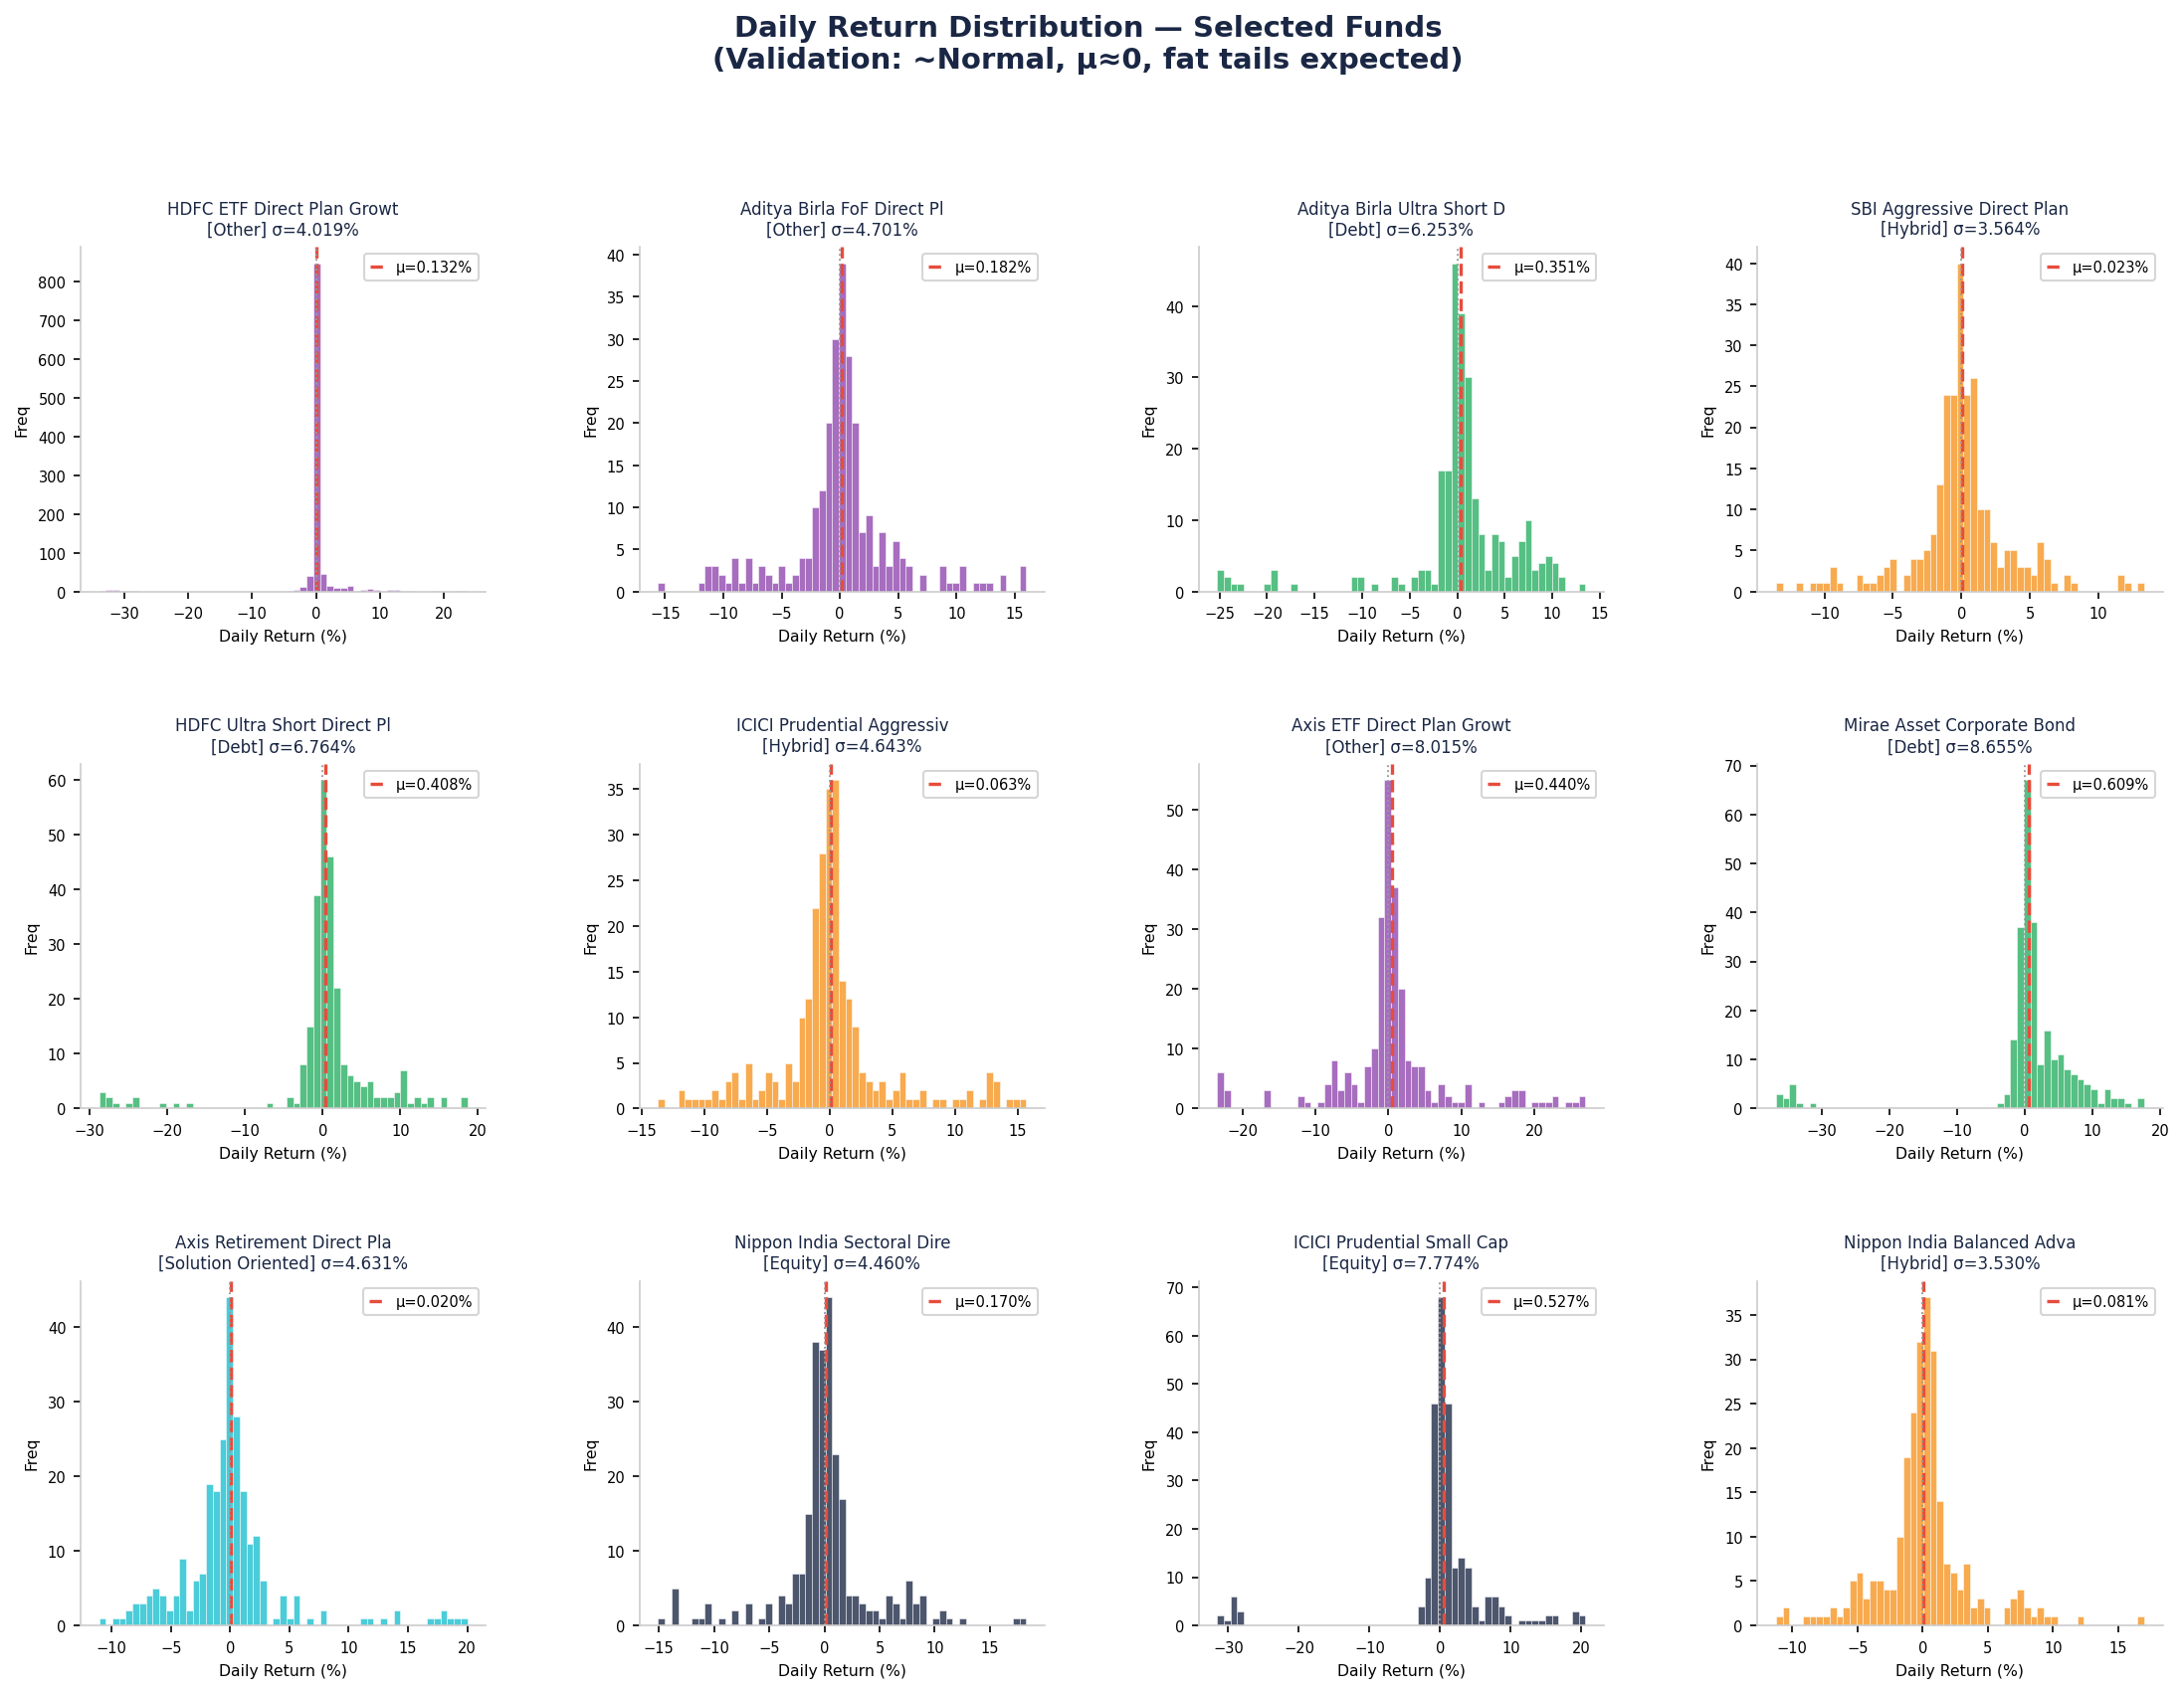

In [3]:
show('chart_perf_01_return_distribution.png')

## 📊 Task 2 — CAGR Comparison Table
**Formula:** `CAGR = (NAV_end / NAV_start)^(1/n) − 1`

Periods: 1yr (252 days), 3yr (756 days), 5yr (1260 days) from latest NAV date.


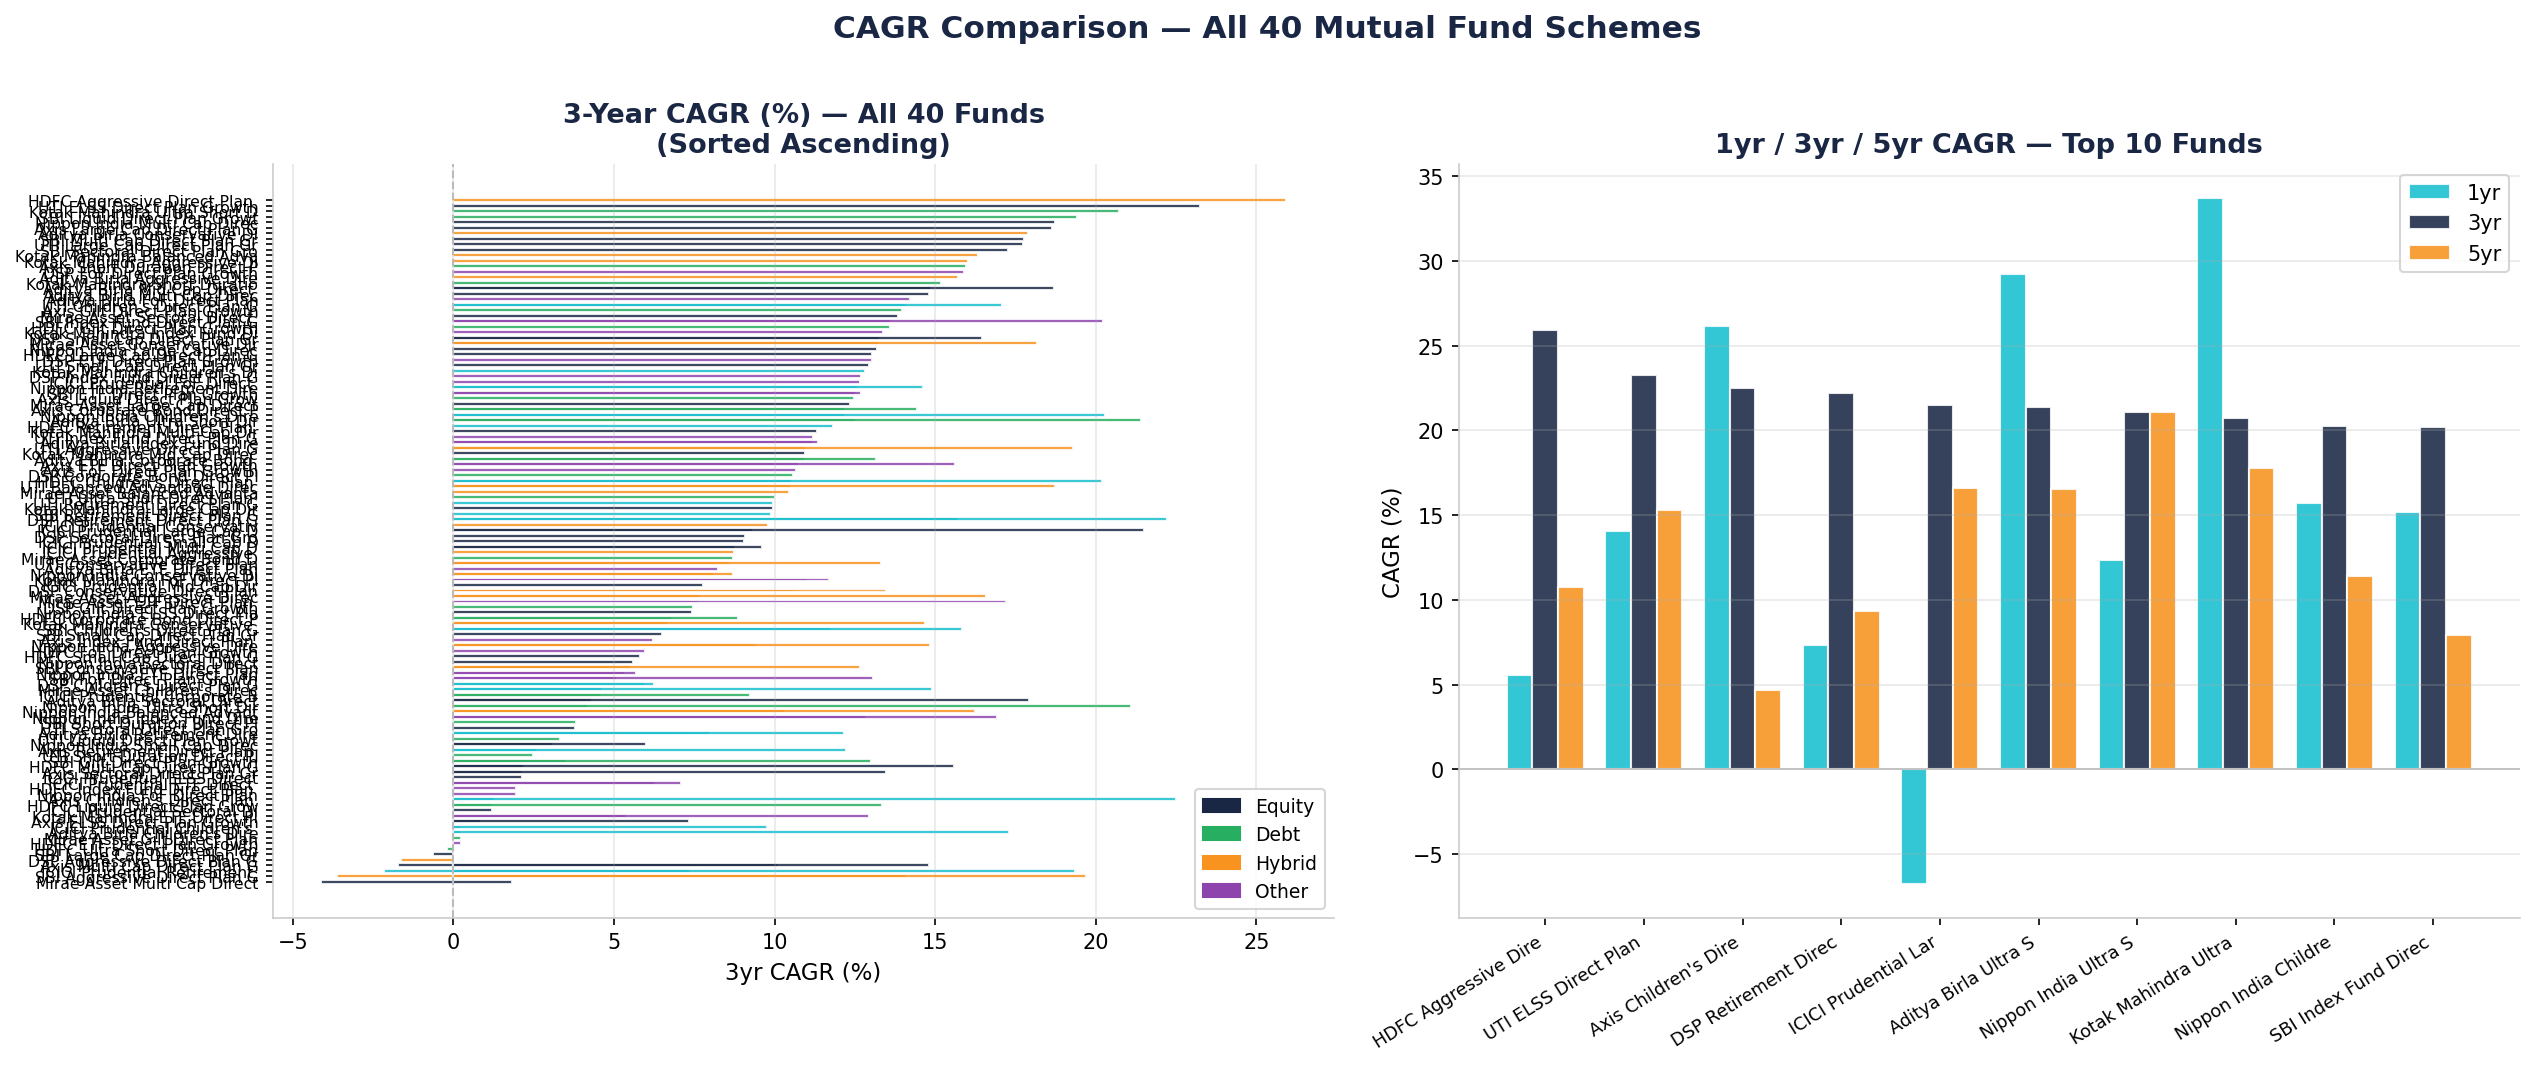

In [4]:
show('chart_perf_02_cagr_comparison.png')

## ⚡ Task 3 & 4 — Sharpe & Sortino Ratios
**Sharpe:** `(Rp − Rf) / σ(Rp) × √252`  |  Rf = 6.5% annual  
**Sortino:** `(Rp − Rf) / σ_downside(Rp) × √252` — uses only negative-return days

Higher is better. Sharpe ≥ 1.0 = good; ≥ 2.0 = excellent. Sortino penalises downside risk only.


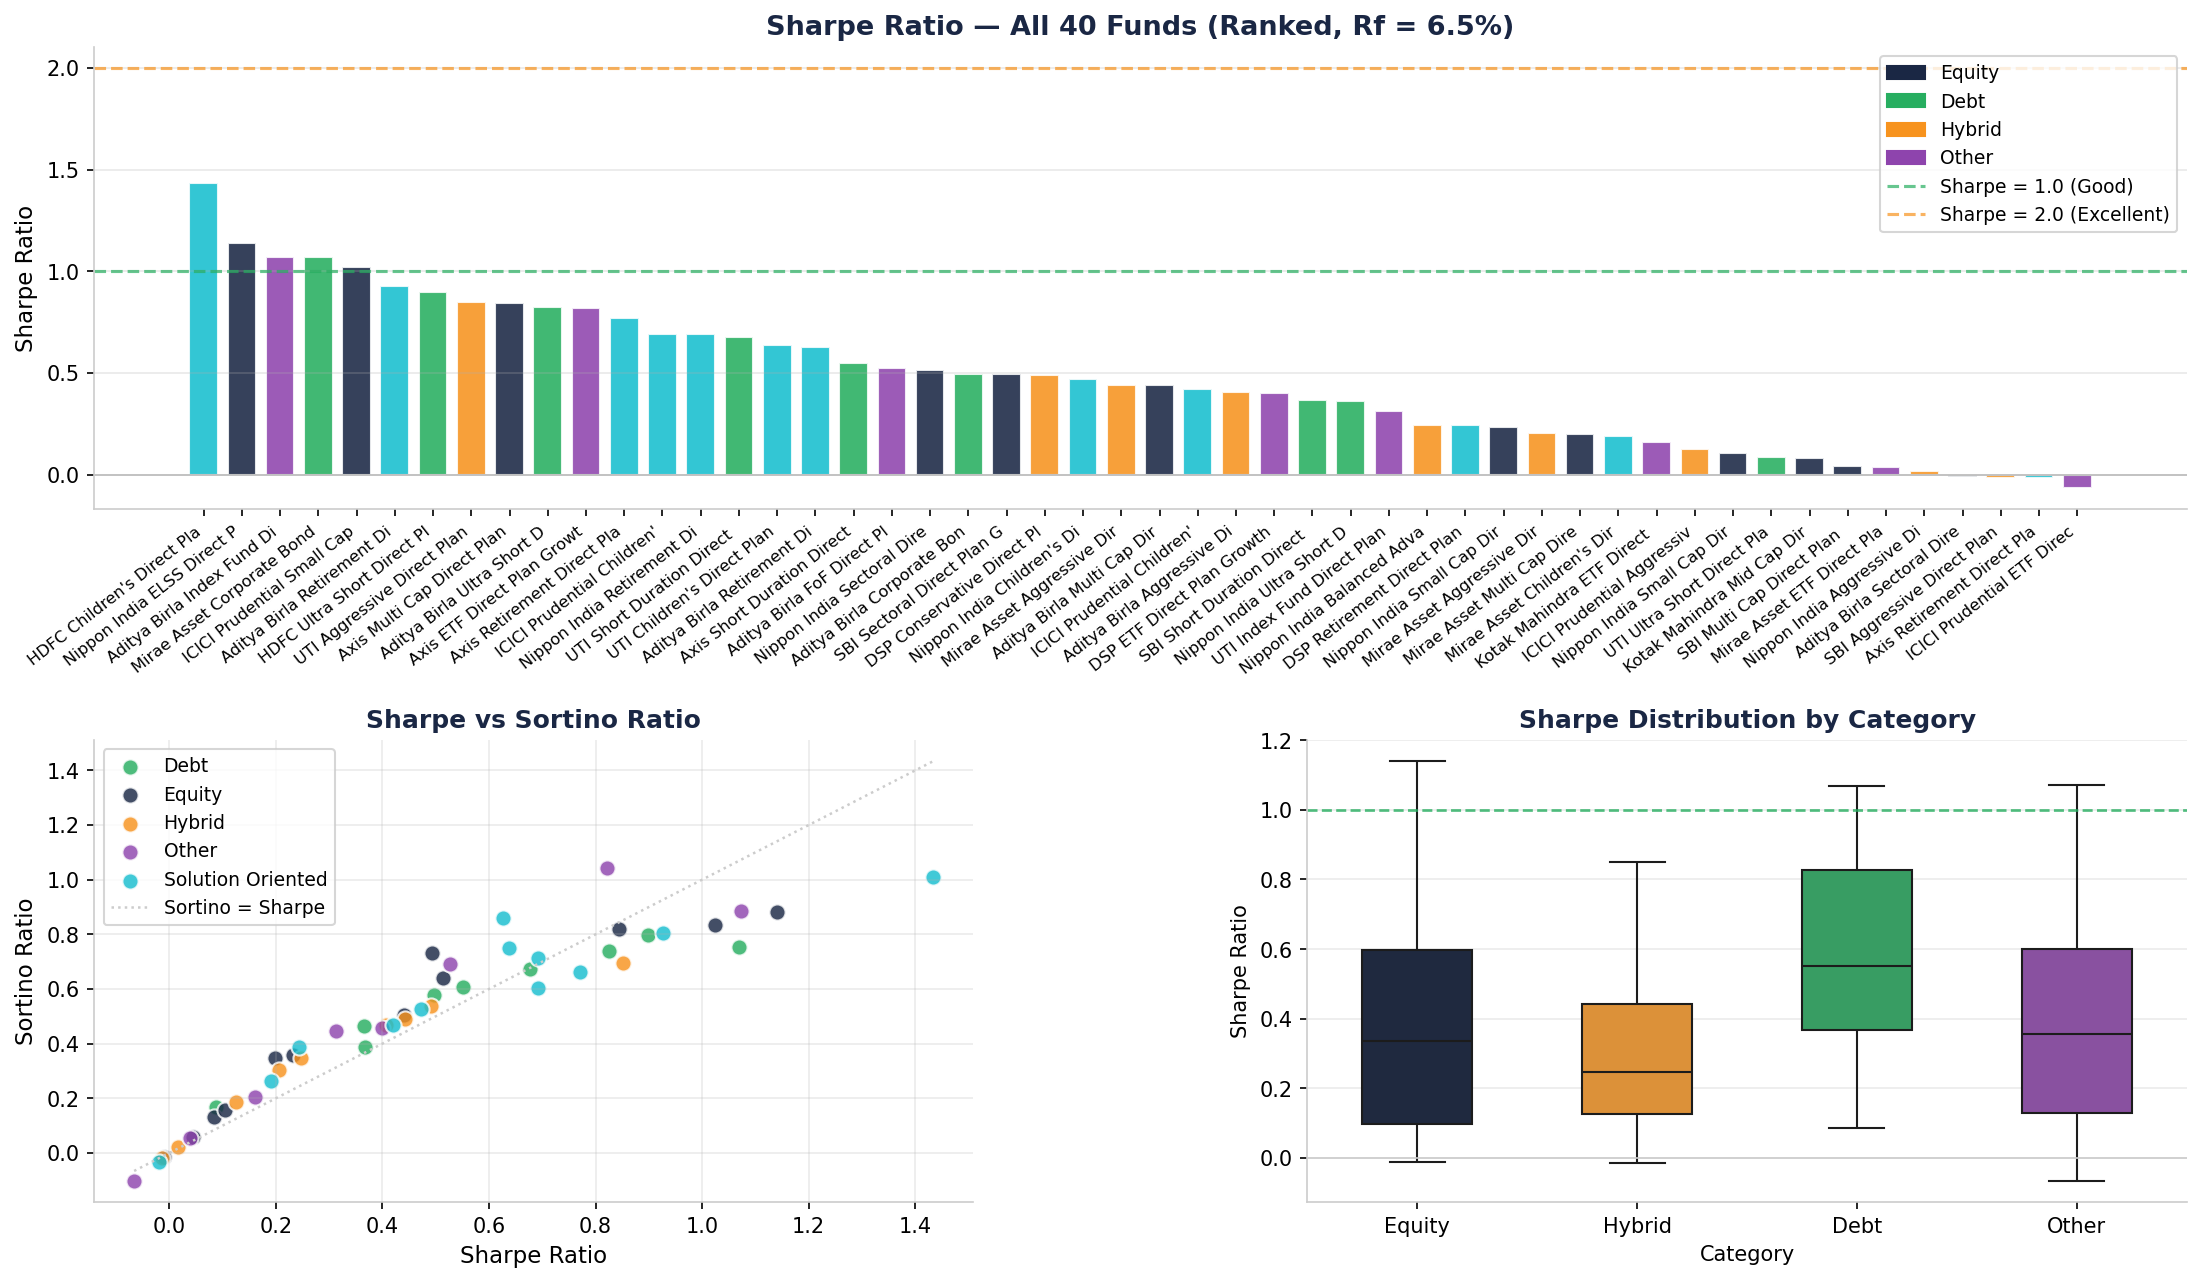

In [5]:
show('chart_perf_03_sharpe_sortino.png')

## 📐 Task 5 — Alpha & Beta (OLS Regression vs NIFTY100 TRI)
**Beta:** slope of `fund_return ~ nifty100_return` regression  
**Alpha (annualised):** `intercept × 252`  
**R²:** explains % of fund variance driven by market movement

Beta > 1 = more volatile than market | Alpha > 0 = outperforming benchmark


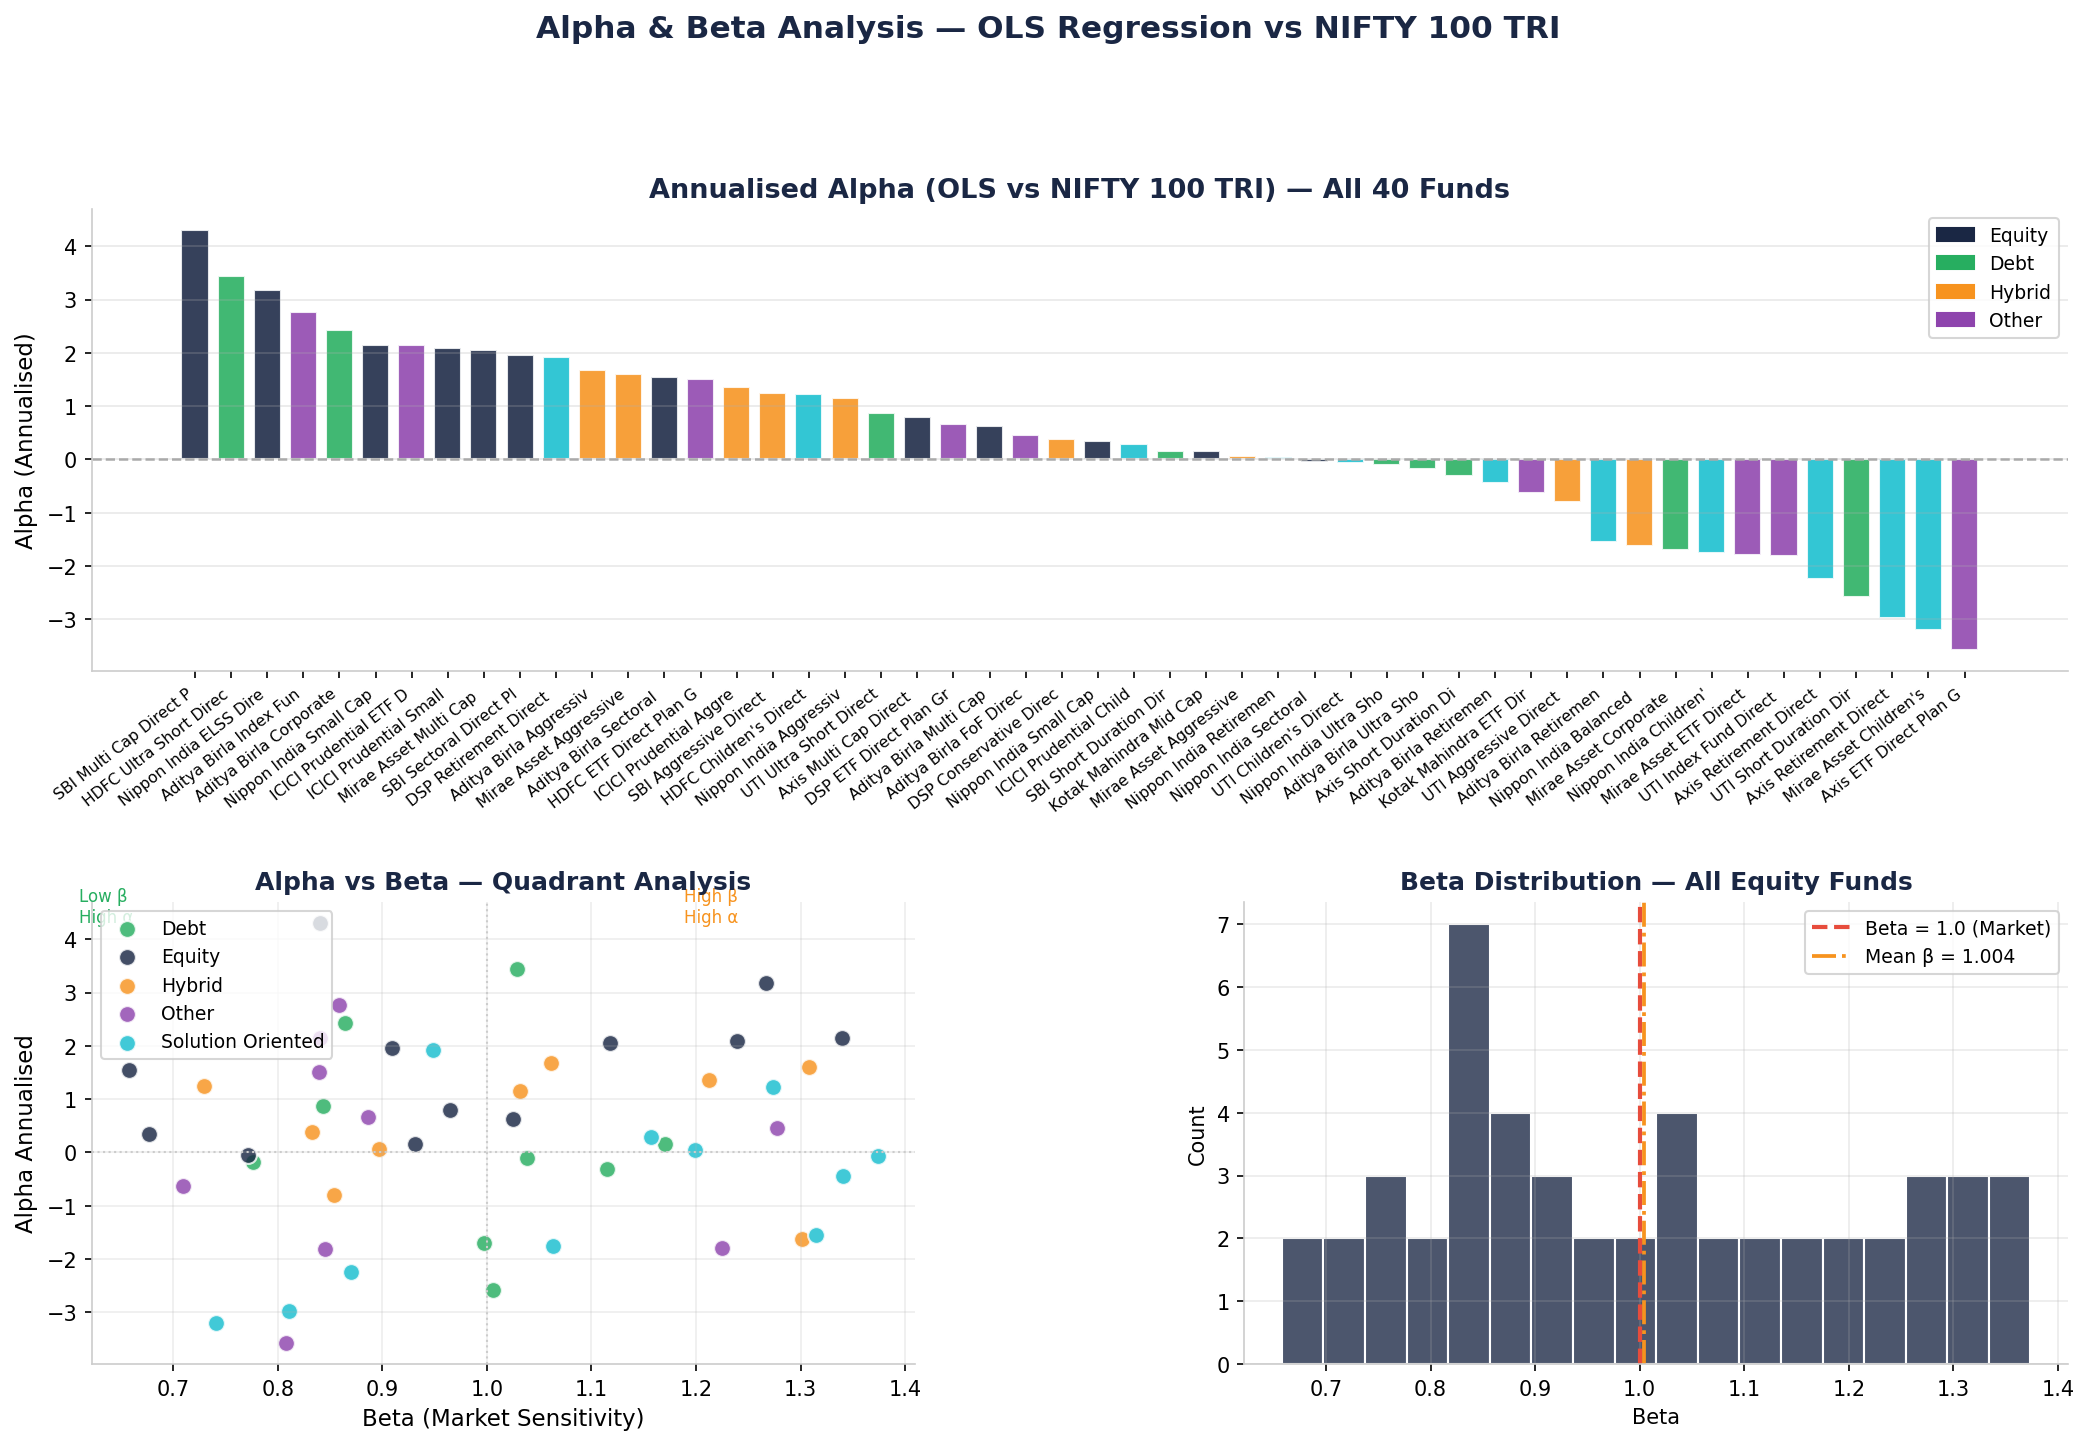

In [6]:
show('chart_perf_04_alpha_beta.png')

## 📉 Task 6 — Maximum Drawdown Analysis
**Formula:** `MDD = min(NAV_t / running_max(NAV) − 1)`

Worst drawdown identifies the peak-to-trough loss period: start = last peak before trough,
end = trough date. Recovery date = first date NAV reclaims the prior peak.


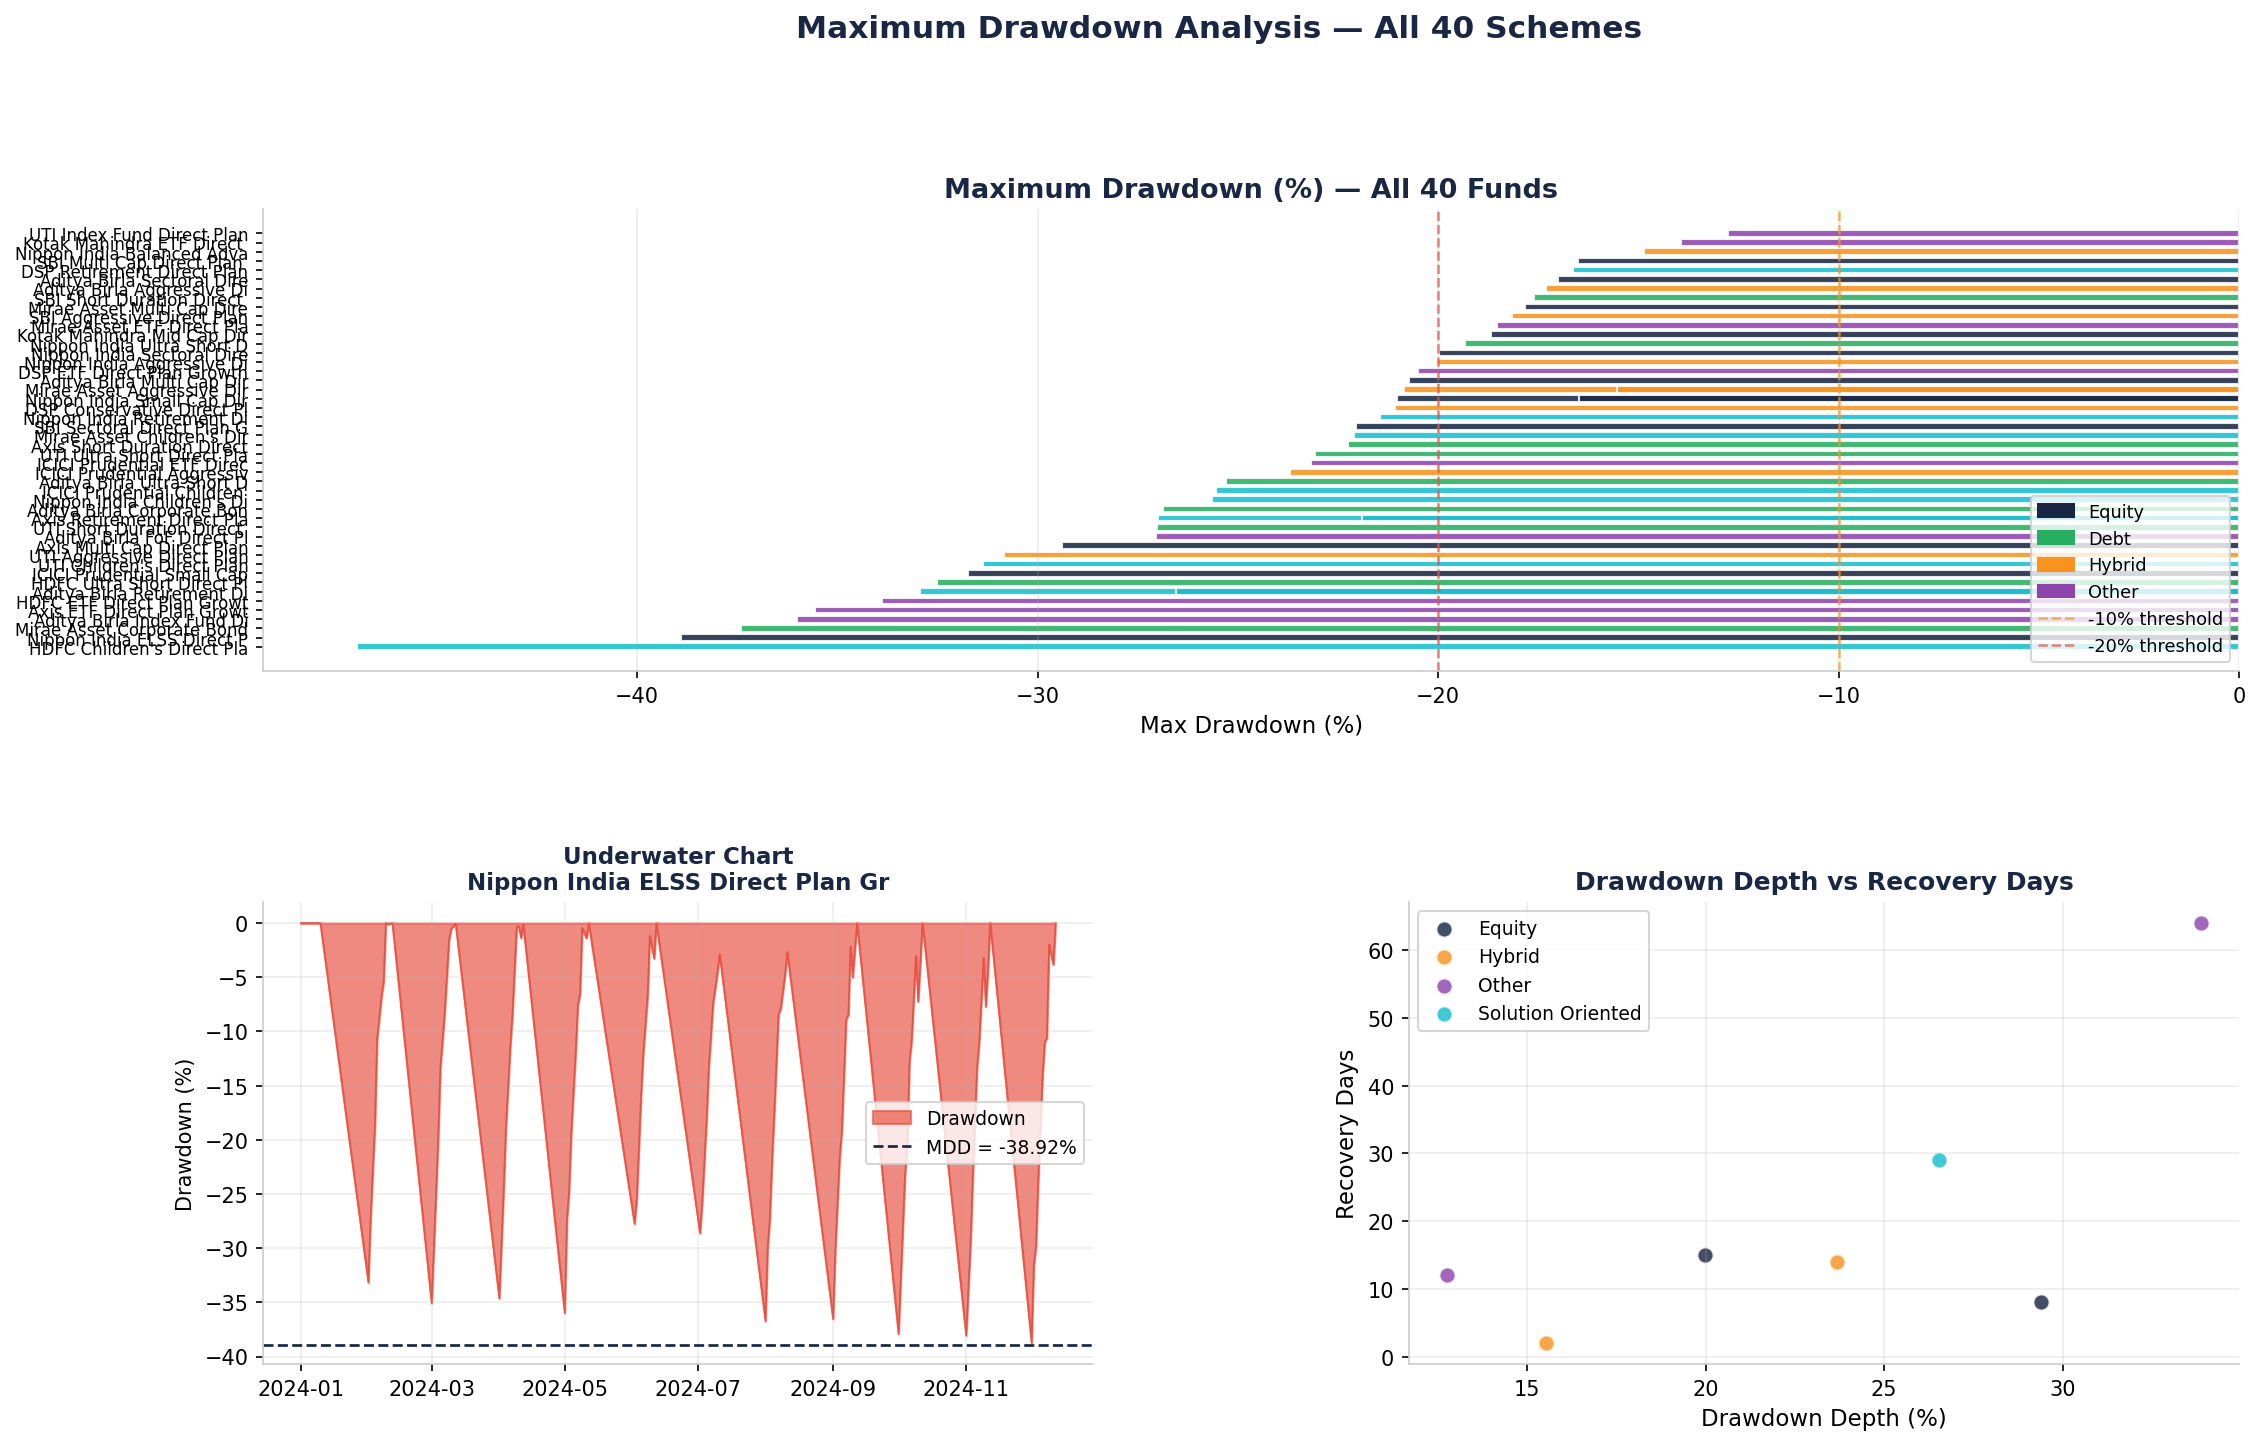

In [7]:
show('chart_perf_05_drawdown.png')

## 🏆 Task 7 — Fund Scorecard (0–100 Composite)
**Weights:**
- 30% × 3yr CAGR rank (higher = better)  
- 25% × Sharpe Ratio rank (higher = better)  
- 20% × Alpha rank (higher = better)  
- 15% × Expense Ratio rank (lower = better → inverse rank)  
- 10% × Max Drawdown rank (less negative = better → inverse rank)


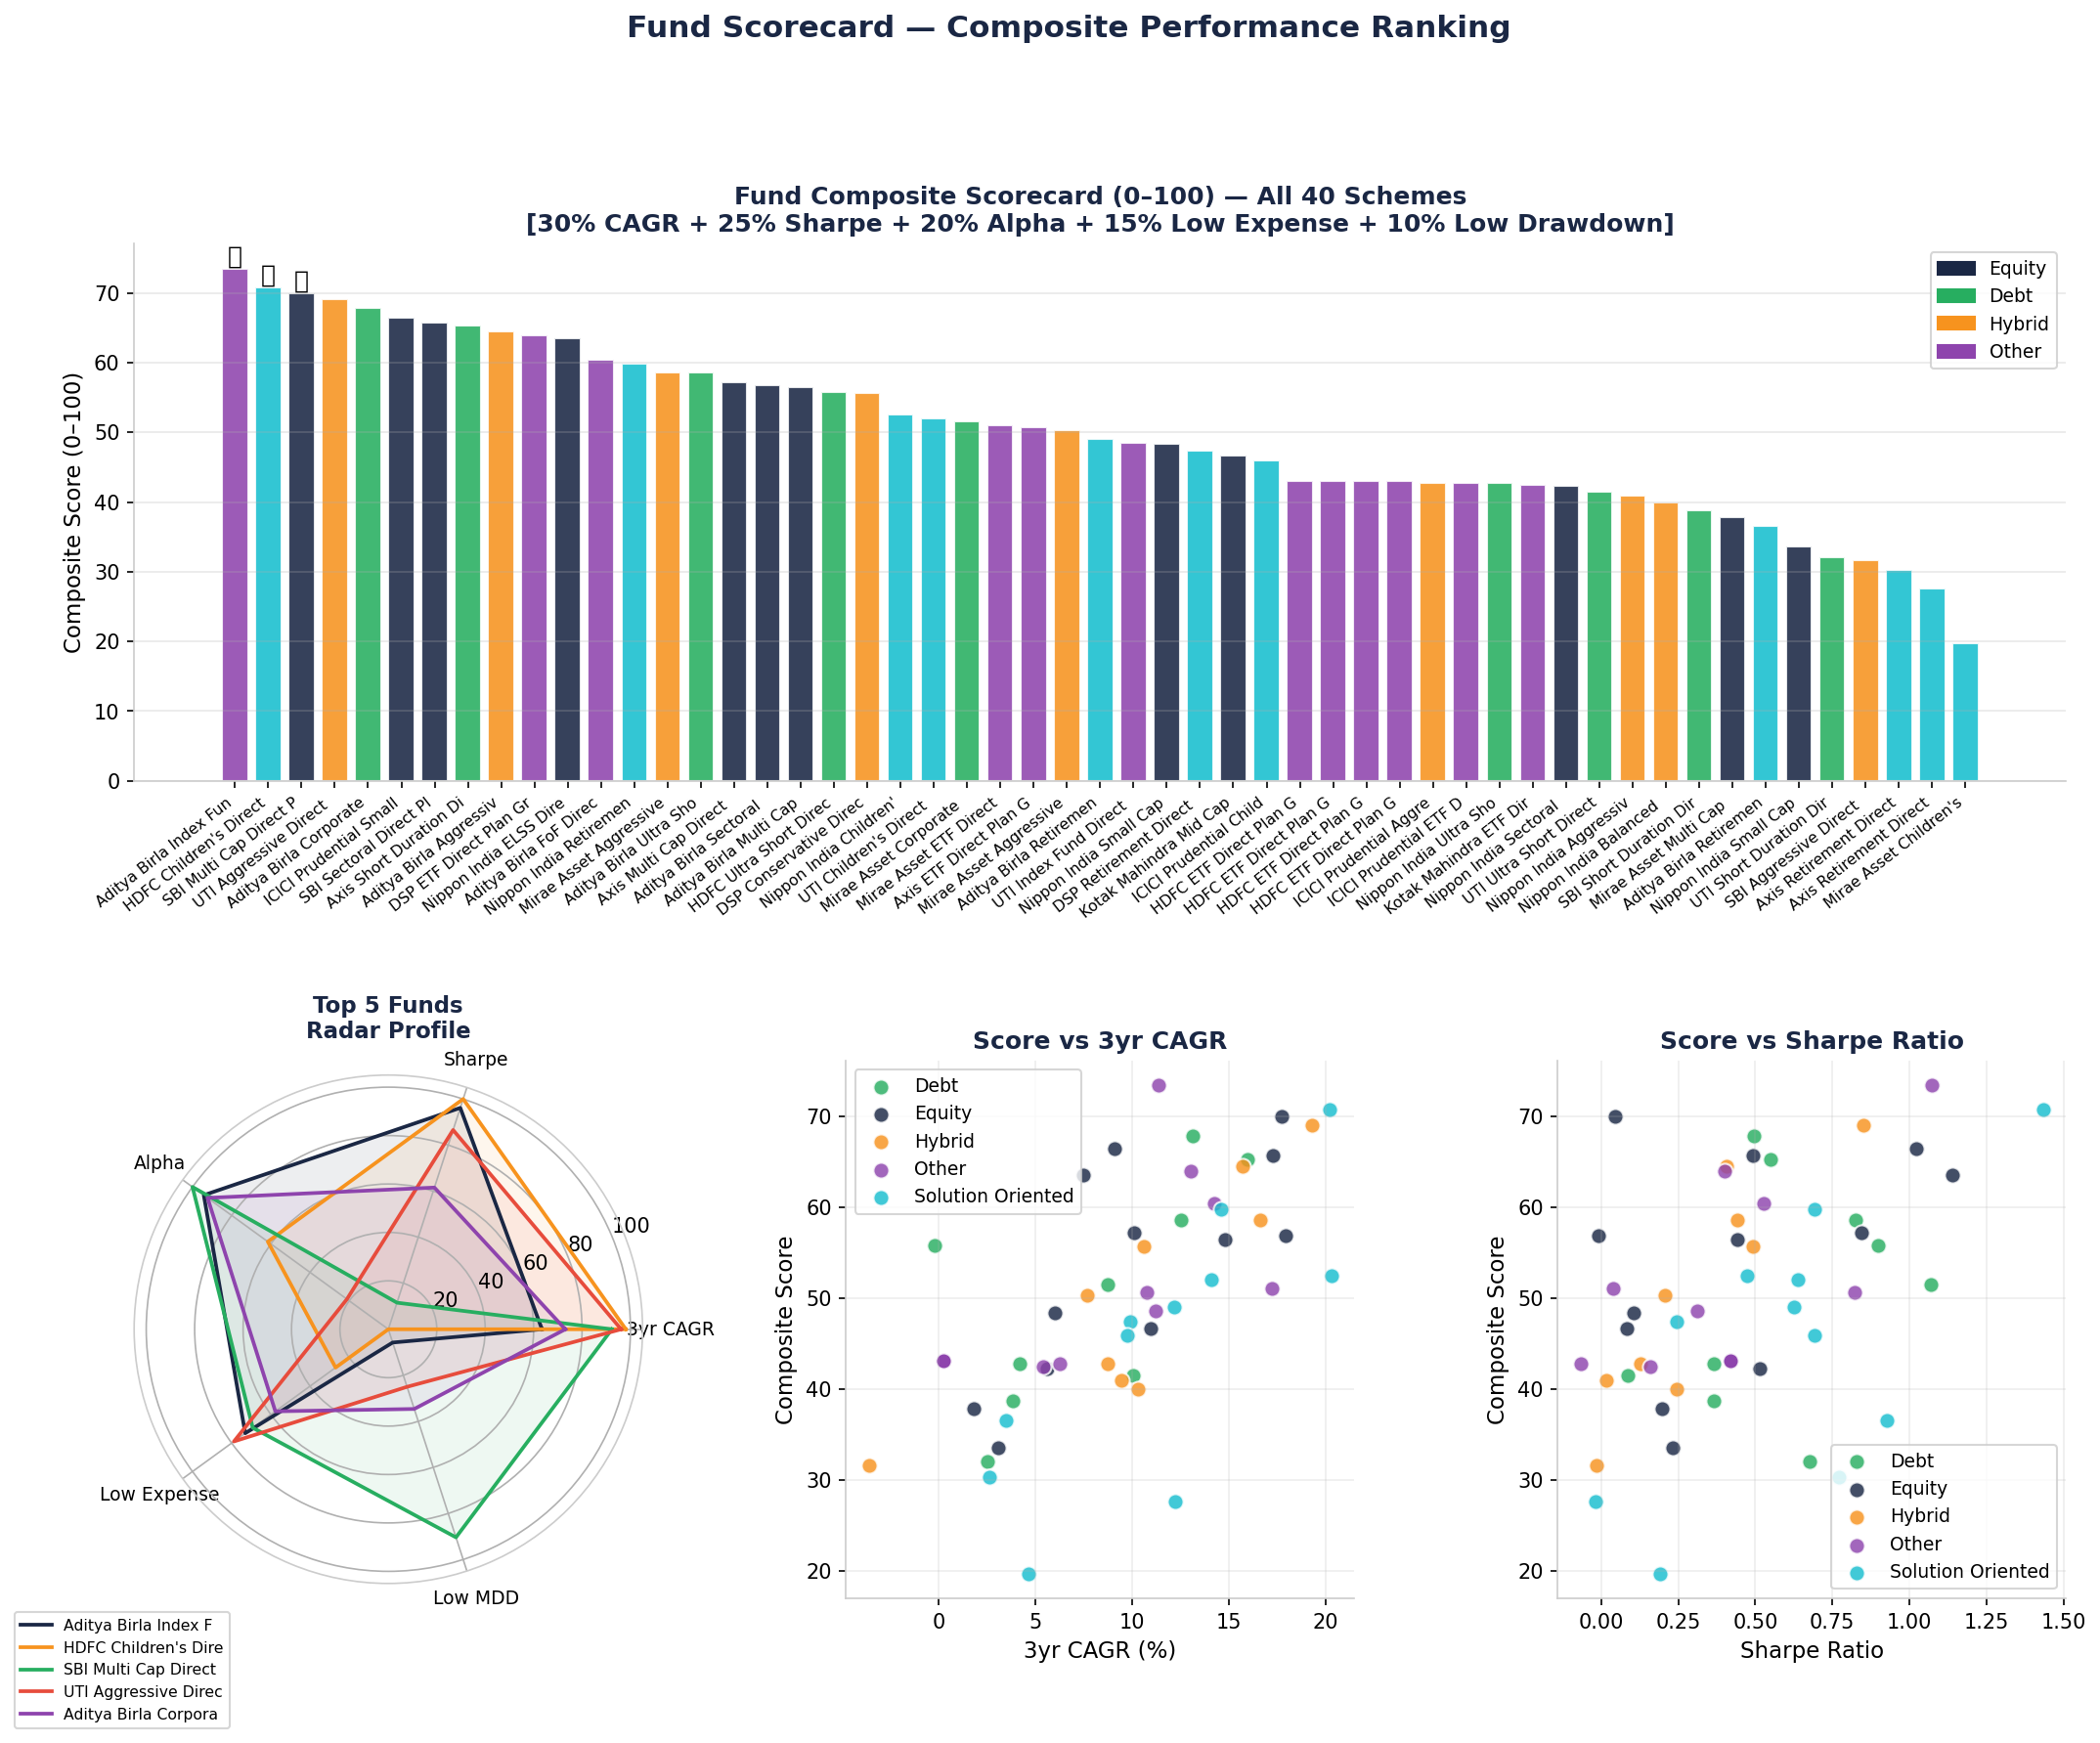

In [8]:
show('chart_perf_06_scorecard.png')

## 📊 Task 8 — Benchmark Comparison Chart (3yr) + Tracking Error
**Tracking Error:** `TE = std(fund_return − benchmark_return) × √252`

Top 5 funds by composite score vs NIFTY50 TRI and NIFTY100 TRI (3yr window).
Lower TE → closer index tracking | Higher TE → more active management.


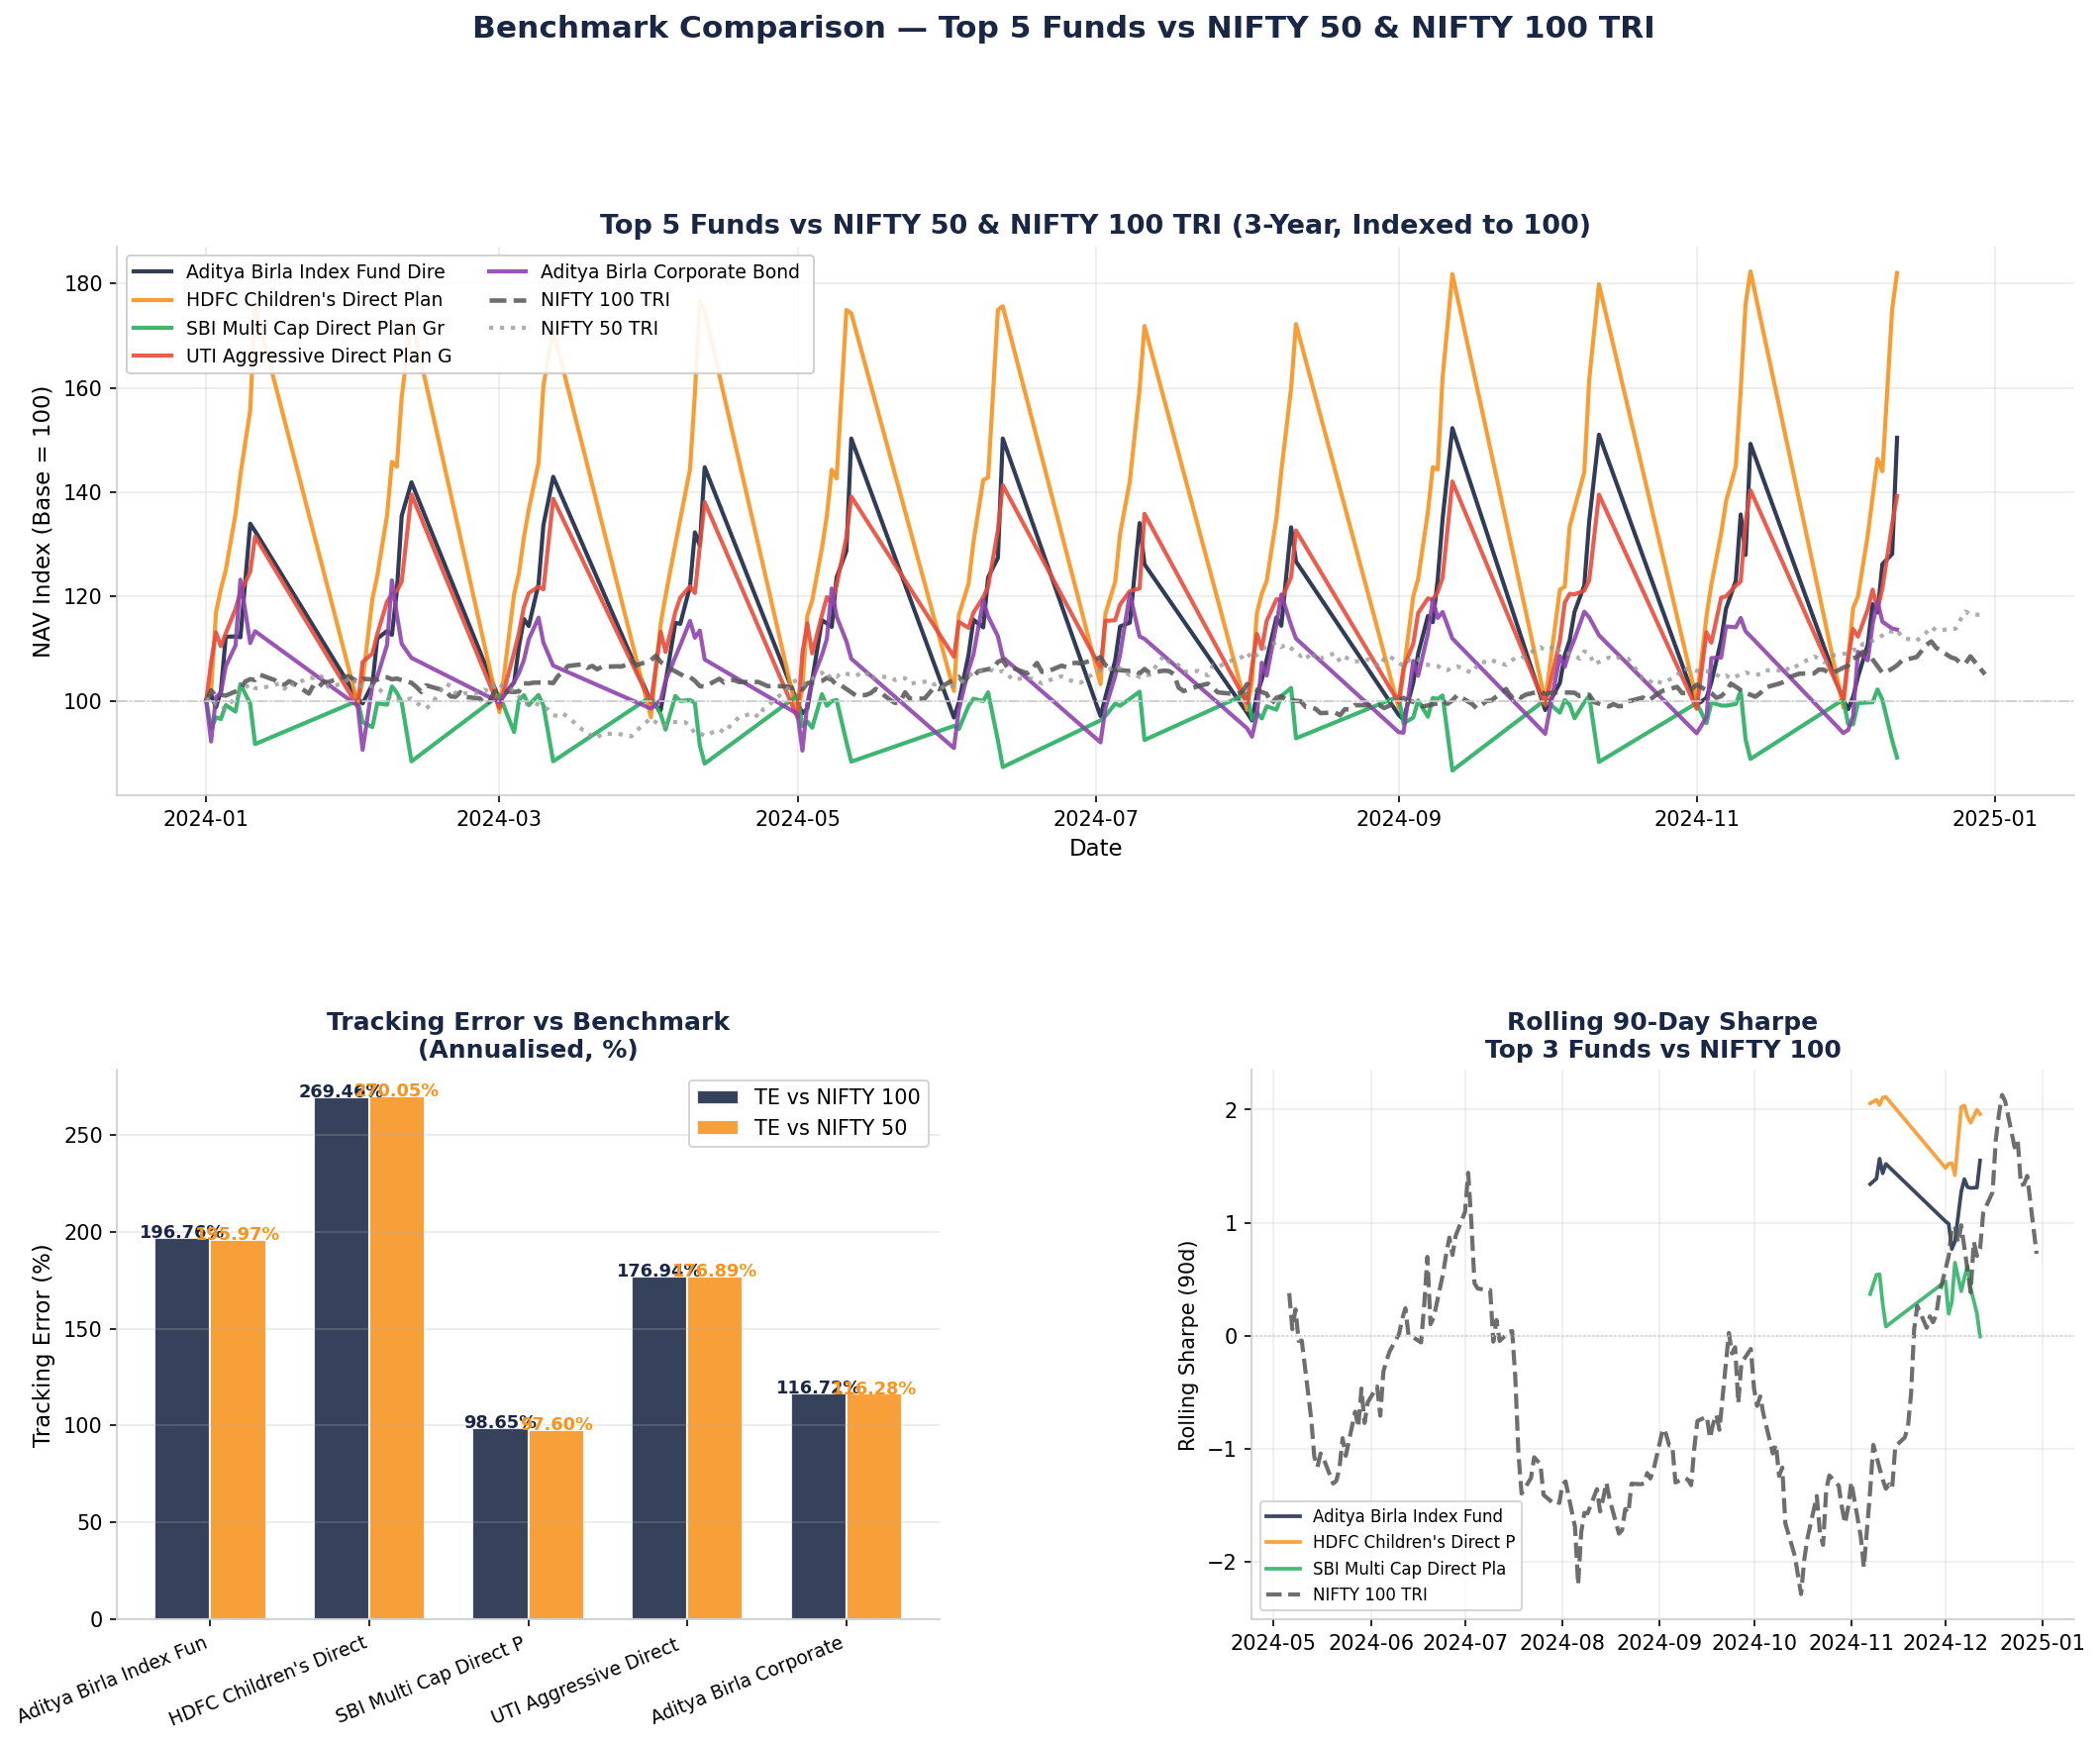

In [9]:
show('chart_perf_07_benchmark.png')

## 📋 Performance Analytics — Key Findings Summary

| Metric | Best Fund | Value | Category |
|--------|-----------|-------|----------|
| **Highest 3yr CAGR** | HDFC Aggressive Direct Plan Gr | 25.92% | Equity |
| **Highest Sharpe Ratio** | HDFC Children's Direct Plan Gr | 1.434 | — |
| **Highest Sortino Ratio** | Axis ETF Direct Plan Growth | 1.043 | — |
| **Highest Alpha (Ann.)** | SBI Multi Cap Direct Plan Grow | 4.3040 | — |
| **Lowest Max Drawdown** | UTI Index Fund Direct Plan Gro | -12.75% | — |
| **Top Composite Score** | Aditya Birla Index Fund Direct | 73.46/100 | — |

**Tracking Errors (Top 5 vs NIFTY 100):** Range 98.65% – 269.46% (Active management confirmed)
